# **Etude cas 1 :** Données simulées

## **SIMULATION DU MODELE SIR :**

In [ ]:
install.packages("deSolve")
library(deSolve)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



   time         S          I         R
1     0 99.000000  1.0000000  0.000000
2     1 96.517462  2.6360069  0.846531
3     2 90.449941  6.5392804  3.010778
4     3 77.832396 14.1488704  8.018734
5     4 58.445816 23.9868513 17.567332
6     5 38.657351 29.9965107 31.346139
7     6 24.642027 29.0024772 46.355496
8     7 16.537160 23.8125493 59.650291
9     8 12.104948 17.8448408 70.050211
10    9  9.639392 12.7185037 77.642105
11   10  8.214411  8.8112265 82.974363
12   11  7.359612  6.0032879 86.637100
13   12  6.831379  4.0488468 89.119774
14   13  6.497742  2.7134306 90.788827
15   14  6.283745  1.8111437 91.905112
16   15  6.145023  1.2057482 92.649229
17   16  6.054450  0.8013548 93.144196
18   17  5.995026  0.5320001 93.472974


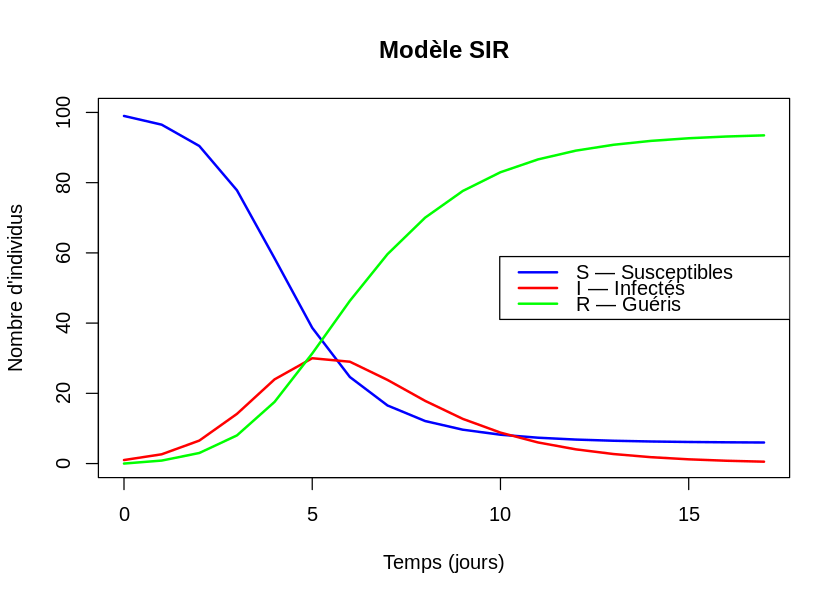

In [ ]:
# Paramètres du modèle
beta  = 1.5
gamma = 0.5

# Conditions initiales
S0 = 99
I0 = 1
R0 = 0

# Population totale
N = S0 + I0 + R0

# Temps de simulation
temps = seq(0, 17, by = 1)

# ==================================================
# FONCTION MODELE SIR
# ==================================================

modele_sir <- function(temps, etat, parametres) {

  S <- etat[1]
  I <- etat[2]
  R <- etat[3]

  beta  = parametres[1]
  gamma = parametres[2]

  # Équations différentielles
  dS = -beta * S * I / N
  dI =  beta * S * I / N - gamma * I
  dR =  gamma * I

  list(c(dS, dI, dR))
}

# ==================================================
# FONCTION DE SIMULATION
# ==================================================

simuler_sir = function(beta, gamma, S0) {



  # Nombre initial de guéris
  R0 = 0

  # Nombre initial d'infectés
  I0 = 1

  # Population totale fixée
  N = I0 + R0 + S0  #jai changé ca tu peux rechanger aprs si tuv

  # Etat initial
  etat_initial = c(
    S = S0,
    I = I0,
    R = R0
  )

  # Paramètres
  parametres = c(beta, gamma, N)

  # Résolution du système
  resultat = ode(
    y = etat_initial,
    times = temps,
    func = modele_sir,
    parms = parametres
  )

  # Conversion en data frame
  resultat = as.data.frame(resultat)

  return(resultat)
}

# ==================================================
# MODELE VRAI
# ==================================================

resultat_vrai = simuler_sir(beta = 1.5, gamma = 0.5, S0=99)

print(resultat_vrai)

# ==================================================
# GRAPH
# ==================================================
options(repr.plot.width = 7, repr.plot.height = 5)

plot(
  resultat_vrai$time,
  resultat_vrai$S,
  type = "l",
  col  = "blue",
  lwd  = 2,
  ylim = c(0, 100),
  xlab = "Temps (jours)",
  ylab = "Nombre d'individus",
  main = "Modèle SIR"
)

lines(resultat_vrai$time, resultat_vrai$I, col = "red",   lwd = 2)
lines(resultat_vrai$time, resultat_vrai$R, col = "green", lwd = 2)

legend(
  "right",
  legend = c("S — Susceptibles", "I — Infectés", "R — Guéris"),
  col    = c("blue", "red", "green"),
  lwd    = 2
)



# ***Simulation ABC-Rejet***



In [ ]:
calc_distance <- function(D,D_star){
  sqrt(sum((D$I-D_star$I)^2)) + sqrt( sum((D$R - D_star$R)^2) )
}

On crée une fonction ABC-Rejet qui s'adapte suivant les 4 scénarios

-  Nombres d'infectés et de guéris du jour 1 au jour 17
-  Nombres d'infectés au jour 17
- Nombres d'infectés et de guéris au jour 17  
- Nombres d'infectés et de guéris au jour 10


In [ ]:
# D = aux vrais données ; epsilon  = la tolérance ; n_par = nb de paramètre à estimer ; N = nb de particules ; cas = les différents cas

Algo_ABC_cas = function(D, epsilon, n_par, N , cas ){

    # matrice vide pour stocker les résultats : beta* , gamma* , S0* et la distance
    res <- matrix(ncol = n_par + 1, nrow = N) # pour rajouter S0_star

    #### ABC algorithm ####

    i <- 1  # compteur initiale pour les particules acceptées
    j <- 1  # compteur initiale pour les particules prooposées

    # tant que le nb de particule est inférieur à N
    while (i <= N) {

      # Distibutions a priori
      beta_star <- runif(1,0,3)
      gamma_star <- runif(1,0,1)
      S0_star <- rpois(1,100)

      # simulation des données avec le modèle en utilisant les paramètres qui suivent des uniformes
      D_star <- simuler_sir(beta_star, gamma_star,S0_star)

      # Calcul de la distance

      if (cas == 1) {
        # Cas 1 : Distance sur toute la série temporelle
      distance <- calc_distance(D, D_star)
      } else if (cas == 2) {
        # Cas 2 : Distance uniquement sur le nombre FINAL de guéris (R)
        # On compare les derniers points des deux simulations
        distance <- sqrt((D$R[length(D$R)] - D_star$R[length(D_star$R)])^2)

      } else if (cas == 3) {
        # Cas 3 : Distance sur l'état FINAL (I et R)
        distance <- sqrt((D$R[length(D$R)] - D_star$R[length(D_star$R)])^2 )+ sqrt(
                        (D$I[length(D$I)] - D_star$I[length(D_star$I)])^2)
      }else if (cas == 4 )
        # Cas 4 : Distance sur le 10 ème jour (I et R)
        distance <- sqrt((D$R[10] - D_star$R[10])^2 +
                        (D$I[10] - D_star$I[10])^2)

      # test si la distance entre les vrais données et les données simulées sont inférieurs à espilon
      if (distance <= epsilon) {

        # garder les résultats
        res[i, ] <- c(beta_star, gamma_star, S0_star , distance)

        # mise à jour du compteur
        i <- i + 1
      }

        # mise à jour du compteur
      j <- j + 1

      # Calcul du pourcentage d'acceptation : nb d'accepté/nb total
      acc_rate <- i / j


    }
    cat("pourcentage d'acceptation actuel = ", round(i/j, 5), "\n")
    return(as.data.frame(res))
}

In [ ]:
options(repr.plot.width=10, repr.plot.height=30) # pour élargir les graphiques
D = simuler_sir(beta = 1.5, gamma = 0.5, S0 = 99)  # vrais données
N_particule <- 200    # Nb de particules acceptées (ce choix permet de faire tourner plus rapidement le code mais l'estimation est moins précise)
epsilon <- c(20,1,2,2)  # valeur de epsilon (la tolérance)
n_par <- 3      # Nombres de paramètres qui vont être estimés ici (beta, gamma, S0)
cas = c(1,2,3,4) # les 3 différents scénarios + le mm 3ème scénario mais sur le jours 10


all_res_1 <- vector("list", 4) # crée une liste de taille 3


i=1
while(i<=4){
res <- Algo_ABC_cas(D, epsilon[i], n_par , N_particule, cas[i])

# Nommer les 4 colonnes existantes
colnames(res) <- c(
  "beta_star",
  "gamma_star",
  "S0_star",
  "dist"
)

# Ajouter une 5e colonne
res$R0_star <- ifelse(
  res$gamma_star != 0,
  res$beta_star / res$gamma_star,
  Inf
)

all_res_1[[i]] <- res #stoke les matrices dans all_res

i = i + 1

}


pourcentage d'acceptation actuel =  0.0036 
pourcentage d'acceptation actuel =  0.03608 
pourcentage d'acceptation actuel =  0.0404 
pourcentage d'acceptation actuel =  0.00398 


**On simule le code du dessus 5 fois et à la fin on les met ensemble avec la fonction ci-dessous**

In [ ]:

all_res_N1000 <- vector("list", length(all_res_1))

for(i in seq_along(all_res_1)){
  all_res_N1000[[i]] <- rbind(
    all_res_1[[i]],
    all_res_2[[i]],
    all_res_3[[i]],
    all_res_4[[i]],
    all_res_5[[i]]
  )
}

**On télécharge ces données en gardant la même structure en utilisant**
- saveRDS(all_res_N1000, file = "/content/all_res_N1000.rds")

**Et lorsqu'on veut utiliser ce matrice de matrice, on le met dans l'environnement Google Collab et on utilise cette formule pour récuperer ces données**
- all_res_N1000 <- readRDS("/content/all_res_N1000.rds")


**Le code ci-dessous permet d'afficher les trajectoires des infectés et des guéris simulées et théoriques à partir des paramètres acceptés de l'ABC-Rejet**

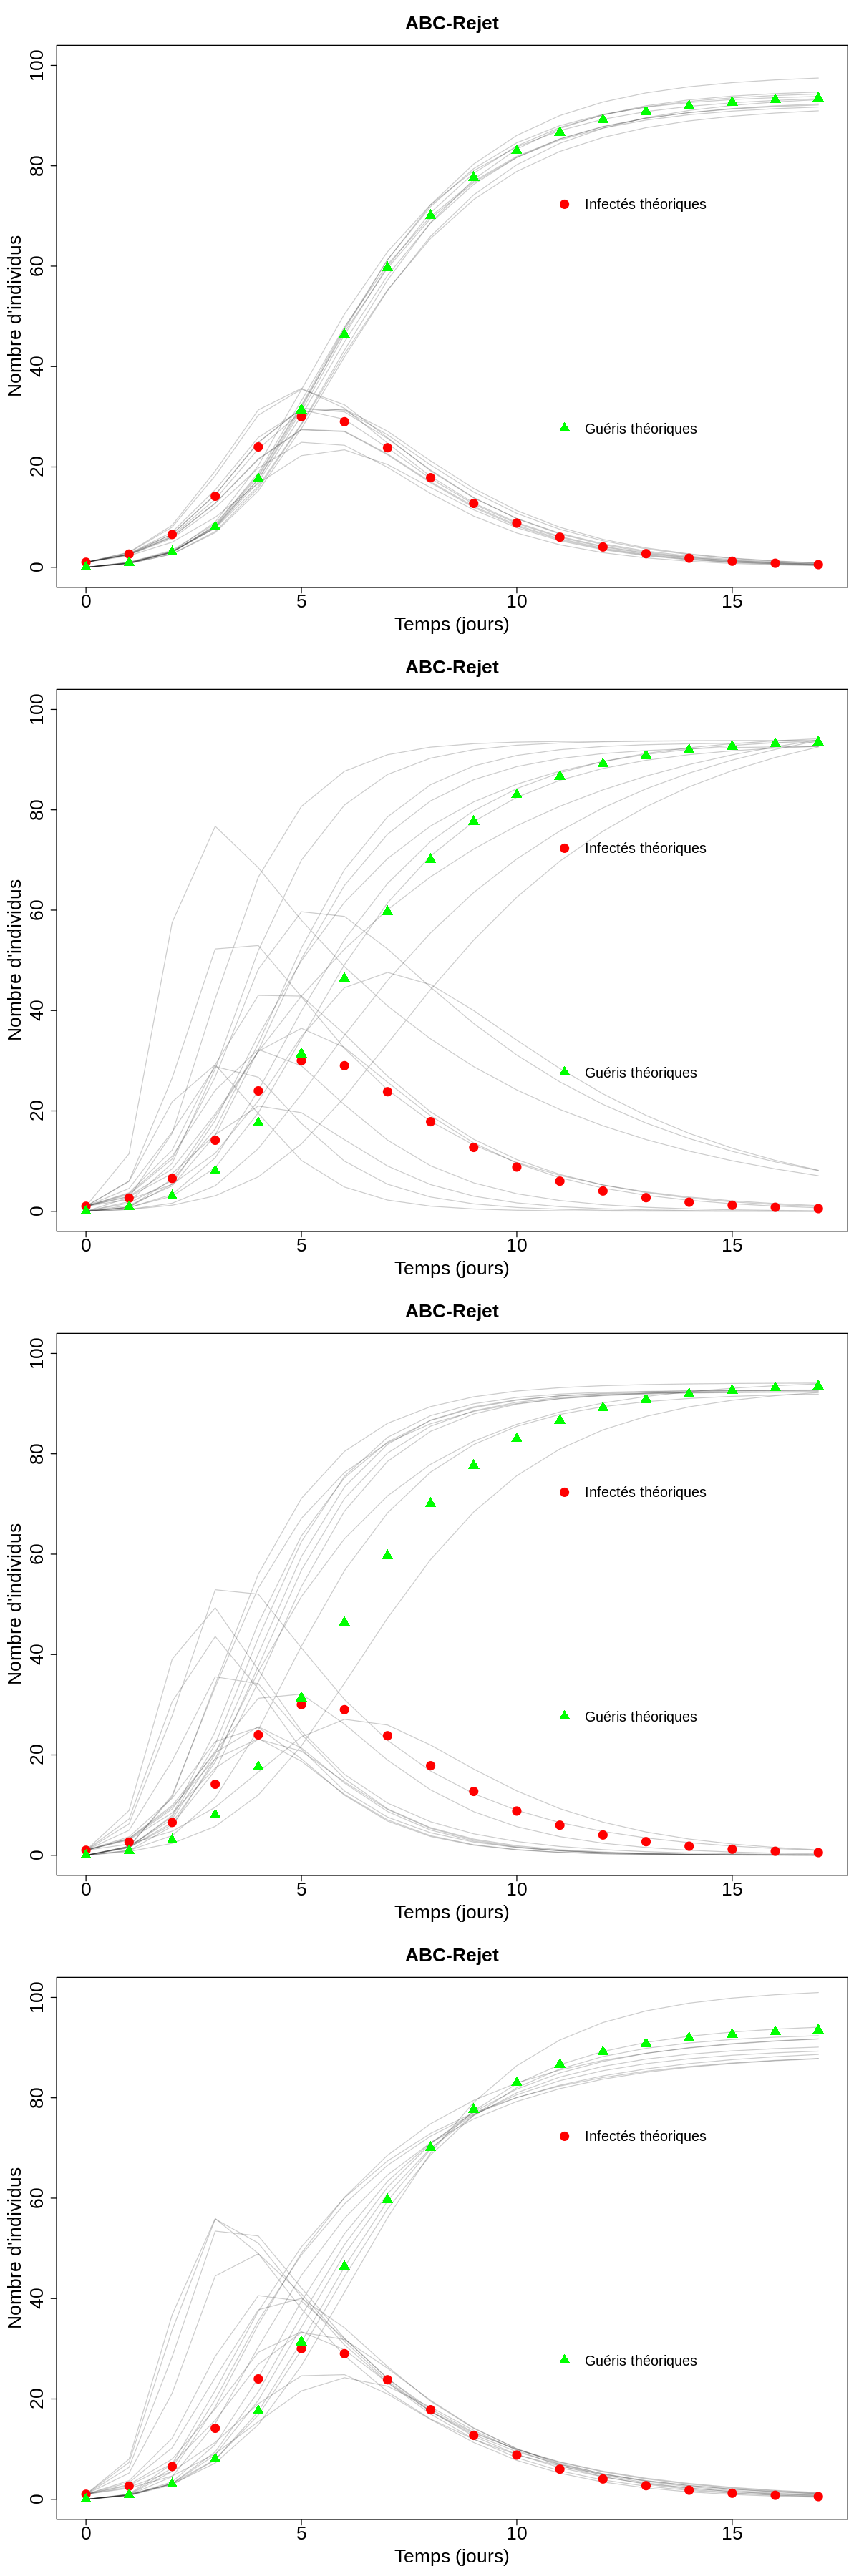

In [ ]:
options(repr.plot.width=10, repr.plot.height=30) # pour élargir les graphiques
D = simuler_sir(beta = 1.5, gamma = 0.5, S0 = 99)  # vrais données
par(mfrow = c(4, 1),mar = c(5, 5, 4, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes

i=1
while(i<=4){
res = all_res_N1000[[i]]
# Nommer les 4 colonnes existantes
colnames(res) <- c(
  "beta_star",
  "gamma_star",
  "S0_star",
  "dist"
)

# Ajouter une 5e colonne
res$R0_star <- ifelse(
  res$gamma_star != 0,
  res$beta_star / res$gamma_star,
  Inf
)


# 2. On prépare le graphique vide
plot(NULL,
     xlim = c(0, 17),
     ylim = c(0, 100),
     xlab = "Temps (jours)",
     ylab = "Nombre d'individus",
     main = paste("ABC-Rejet"),
     cex.main = 2, # Augmente la taille du titre principal
     cex.lab = 2, # Augmente la taille des labels d'axes
     cex.axis = 2  # Agrandit les chiffres sur les axes (0, 1, 2, 3...)
     )

indices_visu <- sample(1:nrow(res), 10) # Contient 10 couples (beta, gamma) tirées au hasard
# 3. On trace chaque simulation acceptée
for (k in indices_visu) {
  # On simule le modèle avec le k-ième couple beta/gamma accepté
  D_temp <- simuler_sir(beta = res$beta_star[k],
                        gamma = res$gamma_star[k], S0 = res$S0_star[k])

  # On trace la courbe des Infectés et des guéries
  lines(D_temp$time, D_temp$I, col = rgb(0, 0, 0, 0.2))
  lines(D_temp$time, D_temp$R, col = rgb(0, 0, 0, 0.2))

}

# 4. On ajoute les données réelles par dessus pour comparer
points(D$time, D$I, col = "red", pch = 19, cex = 2 )
points(D$time, D$R, col = "green", pch = 17 , cex = 2 )

legend(
  "right",
  legend = c("Infectés théoriques", "Guéris théoriques"),
  col    = c("red", "green"),
  pch    = c(19, 17),
  cex    = 1.5,         # <--- AGRANDIT la police et les symboles
  pt.cex = 2,
  bty    = "n"         # le n signifi qu'on enlève le cadre blanc de la légende


)
i = i + 1

}

##**Analyse des paramètres acceptés**
Nous allons utiliser les 3 cas avec N le nombre de particule égale à 100.
Les valeurs théoriques des paramètres sont β = 1.5 et γ = 0.5.

#**Type 1 : Données complètes**

**On ce place dans le cas 1 pour les paramètres N = 1000, epsilon = 20. Et on utilise toutes l'informations sur les infectés et les guéris du jour 1 au jour 17.**


In [ ]:
estmated_beta = all_res_N1000[[1]]$beta_star
estmated_gamma = all_res_N1000[[1]]$gamma_star

mean_beta = mean(estmated_beta)
mean_gamma = mean(estmated_gamma)

interv_credible_beta = quantile(estmated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta
interv_credible_gamma = quantile(estmated_gamma, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de gamma

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_beta), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 4), ", ", round(interv_credible_beta[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 4) - round(interv_credible_beta[1], 4),"\n\n")


cat("Pour le paramètre gamma :\n")
cat("  Moyenne des estimations :", round(mean_gamma, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_gamma), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_gamma[1], 4), ", ", round(interv_credible_gamma[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_gamma[2], 4) - round(interv_credible_gamma[1], 4),"\n\n")


Pour le paramètre beta :
  Moyenne des estimations : 1.5056 
  Variance des estimations : 0.0072 
  Intervalle de crédibilité à 95% : [ 1.3582 ,  1.6605 ]
  Largeur de l'intervalle :  0.3023 

Pour le paramètre gamma :
  Moyenne des estimations : 0.5139 
  Variance des estimations : 0.0033 
  Intervalle de crédibilité à 95% : [ 0.4166 ,  0.6304 ]
  Largeur de l'intervalle :  0.2138 



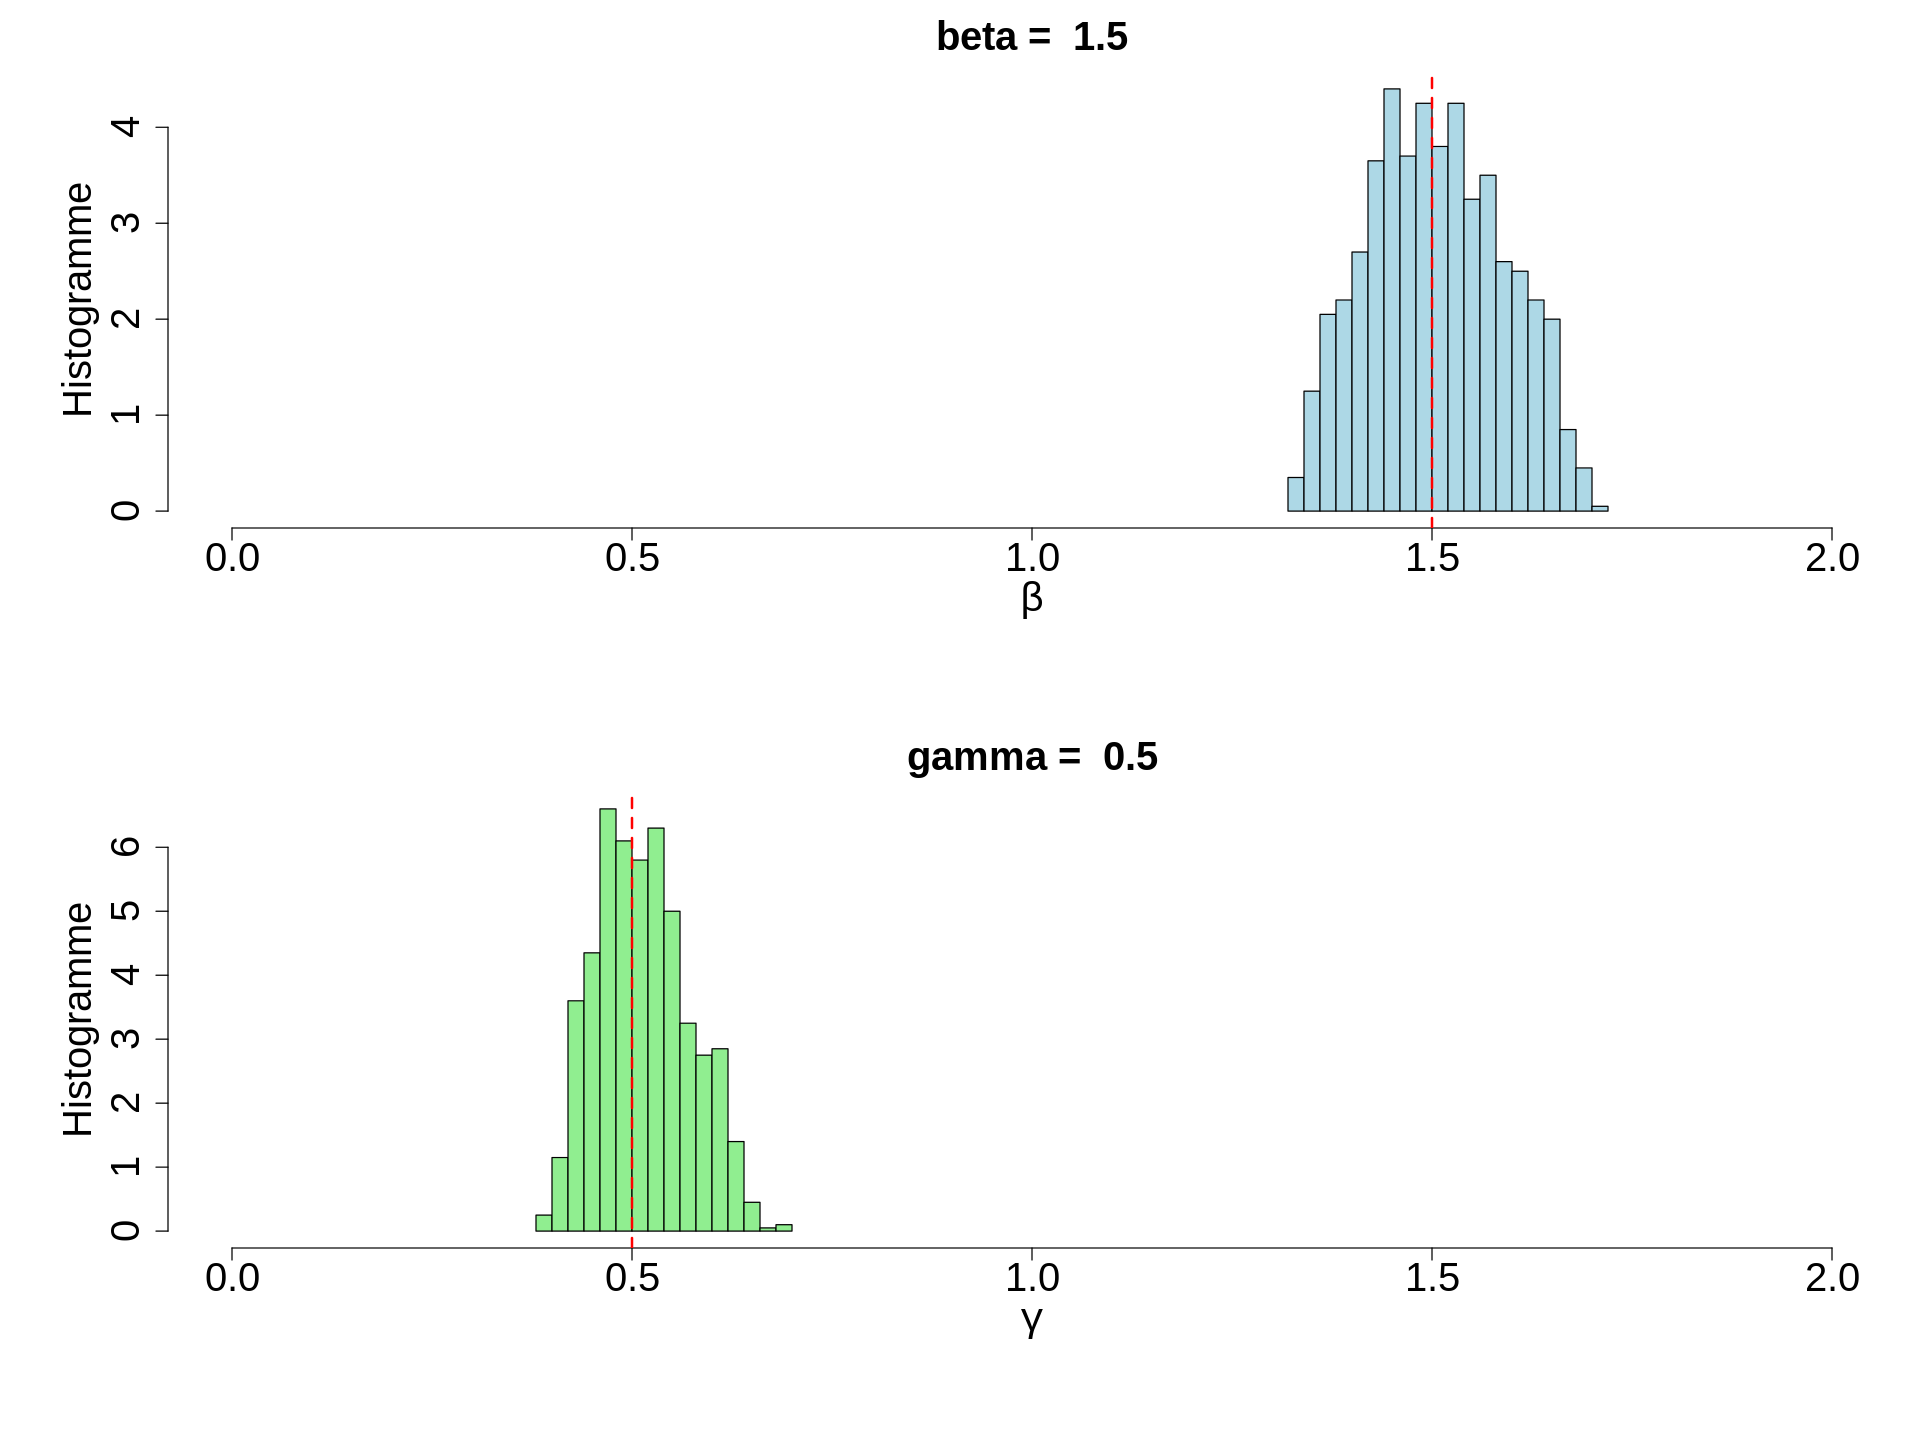

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# Type 1
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

# 1 lignes (cas 1)
# 4 colonnes (S0, beta, gamma, R0)
par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- all_res_N1000[[1]]



  # =================================================
  # HISTOGRAMME BETA
  # =================================================

  hist(
    res$beta_star,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("beta = ", 1.5),
    xlab = expression(beta),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 2)
  )

  abline(
    v = 1.5,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME GAMMA
  # =================================================

  hist(
    res$gamma_star,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "gamma = ", 0.5 ),
    xlab = expression(gamma),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 2)
  )

  abline(
    v = 0.5,
    col = "red",
    lwd = 2,
    lty = 2
  )

##**Type 2 : Le nombre d'infecté et de guéri au jour 17**

**On se place dans le cas 2 pour les paramètres N = 1000, epsilon = 2. Et on a pour information que le nombre d'infecté au jour 17**

In [ ]:
estmated_beta = all_res_N1000[[3]]$beta_star
estmated_gamma = all_res_N1000[[3]]$gamma_star

mean_beta = mean(estmated_beta)
mean_gamma = mean(estmated_gamma)

interv_credible_beta = quantile(estmated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta
interv_credible_gamma = quantile(estmated_gamma, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de gamma

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_beta), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 4), ", ", round(interv_credible_beta[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 4) - round(interv_credible_beta[1], 4),"\n\n")


cat("Pour le paramètre gamma :\n")
cat("  Moyenne des estimations :", round(mean_gamma, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_gamma), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_gamma[1], 4), ", ", round(interv_credible_gamma[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_gamma[2], 4) - round(interv_credible_gamma[1], 4),"\n\n")


Pour le paramètre beta :
  Moyenne des estimations : 2.18 
  Variance des estimations : 0.2531 
  Intervalle de crédibilité à 95% : [ 1.2535 ,  2.9708 ]
  Largeur de l'intervalle :  1.7173 

Pour le paramètre gamma :
  Moyenne des estimations : 0.6061 
  Variance des estimations : 0.0408 
  Intervalle de crédibilité à 95% : [ 0.2903 ,  0.9732 ]
  Largeur de l'intervalle :  0.6829 



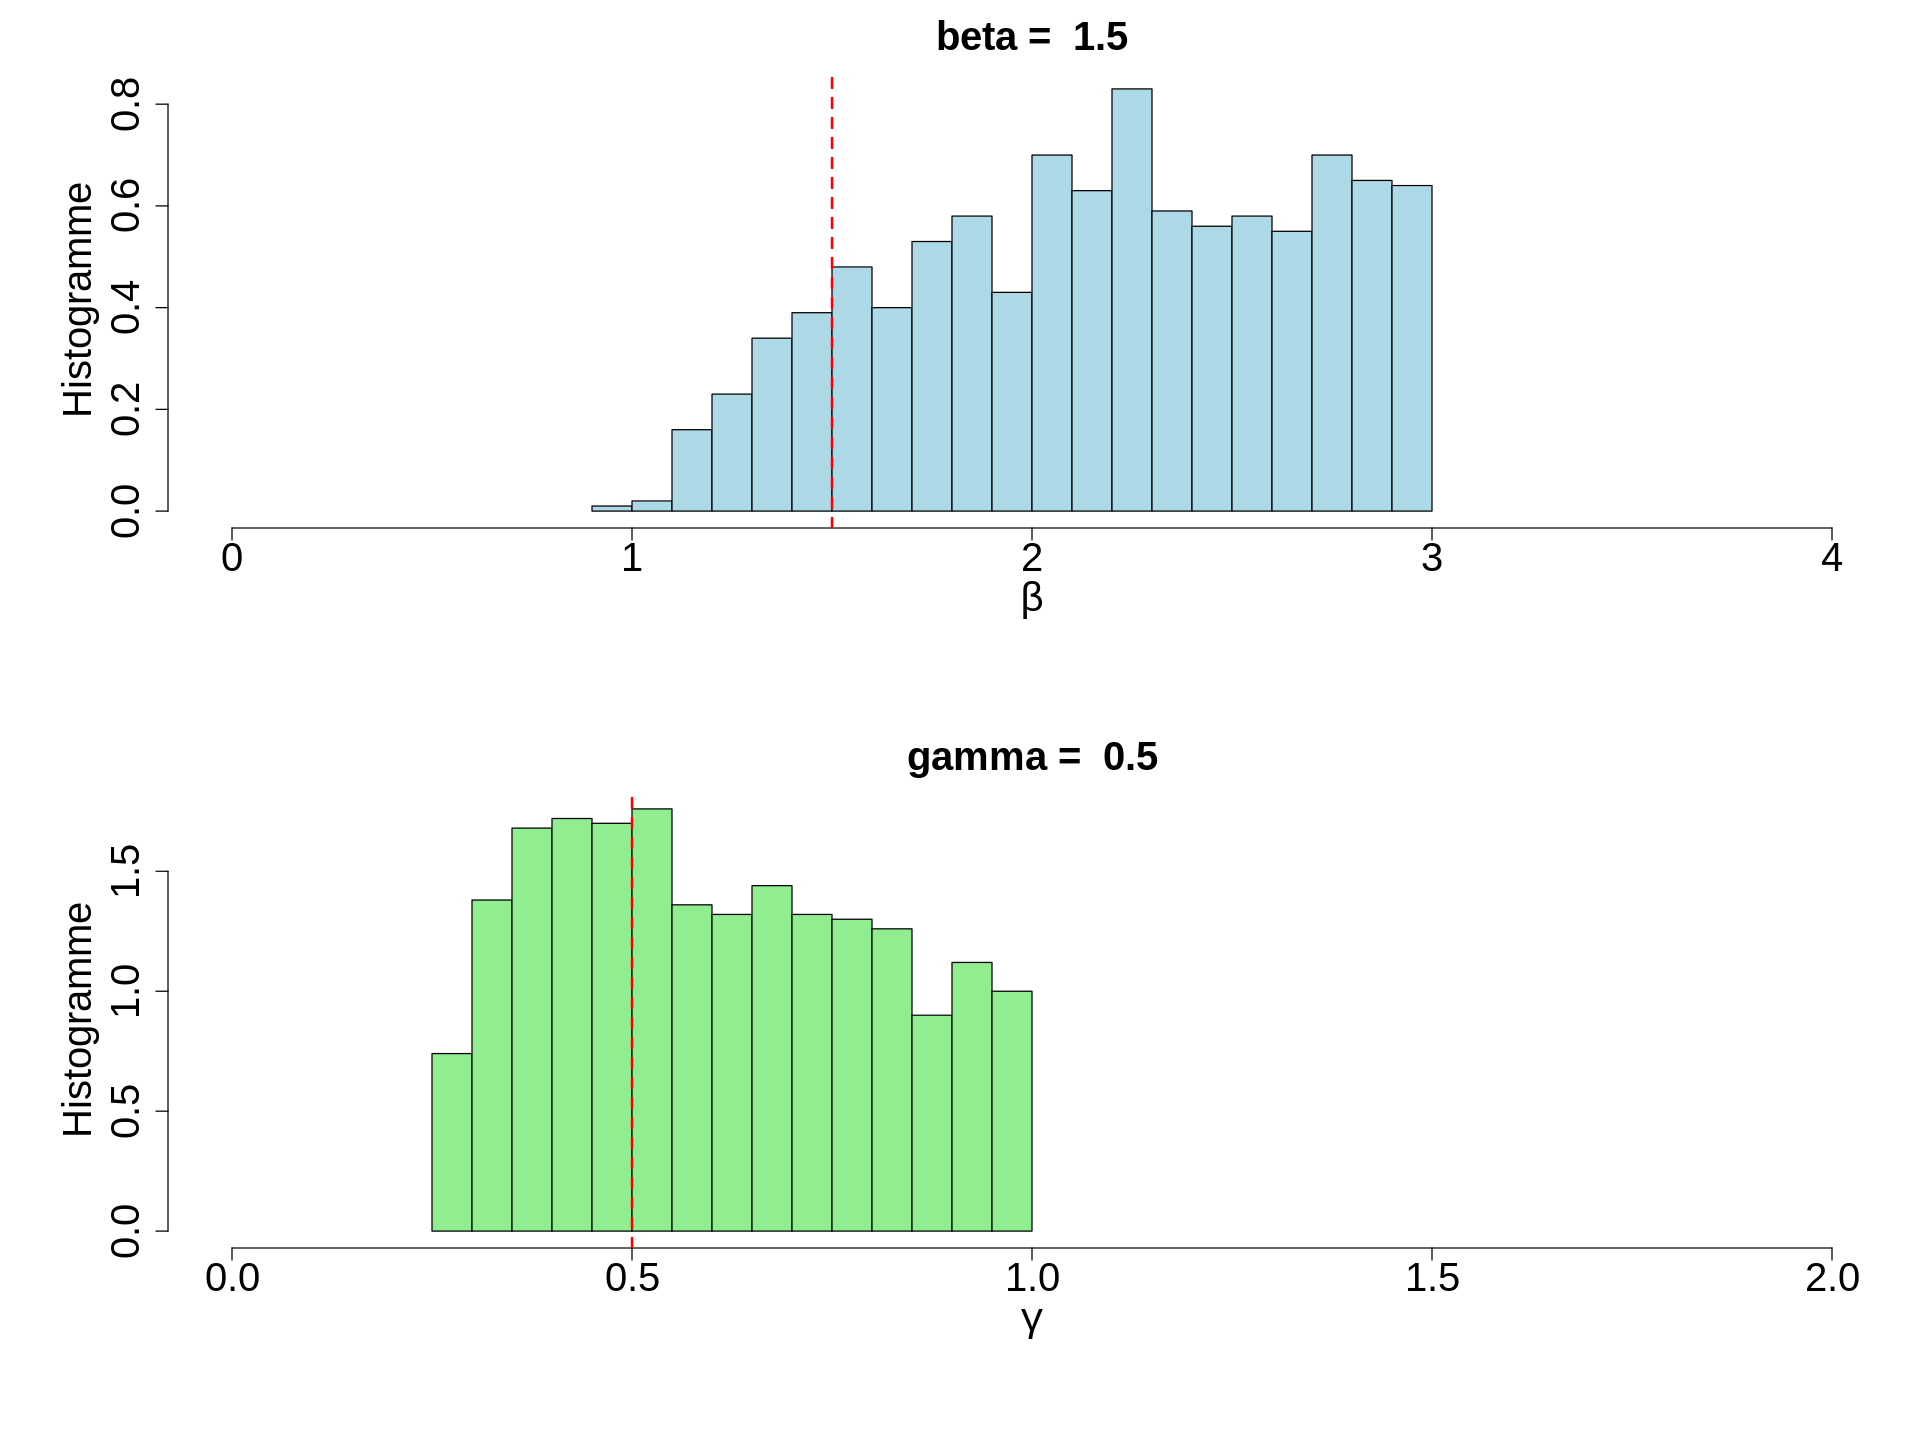

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# Type 2
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

# 1 lignes (cas 1)
# 4 colonnes (S0, beta, gamma, R0)
par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes



  # Résultats du Type 2
  res <- all_res_N1000[[3]]



  # =================================================
  # HISTOGRAMME BETA
  # =================================================

  hist(
    res$beta_star,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("beta = ", 1.5),
    xlab = expression(beta),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 4)
  )

  abline(
    v = 1.5,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME GAMMA
  # =================================================

  hist(
    res$gamma_star,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "gamma = ", 0.5 ),
    xlab = expression(gamma),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 2)
  )

  abline(
    v = 0.5,
    col = "red",
    lwd = 2,
    lty = 2
  )

##**Type 3 : Le nombre d'infecté et de guéri au jour 17**

**On se place dans le cas 3 pour les paramètres N = 1000, epsilon = 1. Et on a pour information que le nombre de guéri au jour 17.**


In [ ]:
estmated_beta = all_res_N1000[[2]]$beta_star
estmated_gamma = all_res_N1000[[2]]$gamma_star

mean_beta = mean(estmated_beta)
mean_gamma = mean(estmated_gamma)

interv_credible_beta = quantile(estmated_beta, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de beta
interv_credible_gamma = quantile(estmated_gamma, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de gamma

cat("Pour le paramètre beta :\n")
cat("  Moyenne des estimations :", round(mean_beta, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_beta), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_beta[1], 4), ", ", round(interv_credible_beta[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_beta[2], 4) - round(interv_credible_beta[1], 4),"\n\n")


cat("Pour le paramètre gamma :\n")
cat("  Moyenne des estimations :", round(mean_gamma, 4), "\n")
cat("  Variance des estimations :", round(var(estmated_gamma), 4), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_gamma[1], 4), ", ", round(interv_credible_gamma[2], 4), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_gamma[2], 4) - round(interv_credible_gamma[1], 4),"\n\n")


Pour le paramètre beta :
  Moyenne des estimations : 2.0878 
  Variance des estimations : 0.3317 
  Intervalle de crédibilité à 95% : [ 0.9445 ,  2.9443 ]
  Largeur de l'intervalle :  1.9998 

Pour le paramètre gamma :
  Moyenne des estimations : 0.5039 
  Variance des estimations : 0.0595 
  Intervalle de crédibilité à 95% : [ 0.1356 ,  0.9682 ]
  Largeur de l'intervalle :  0.8326 



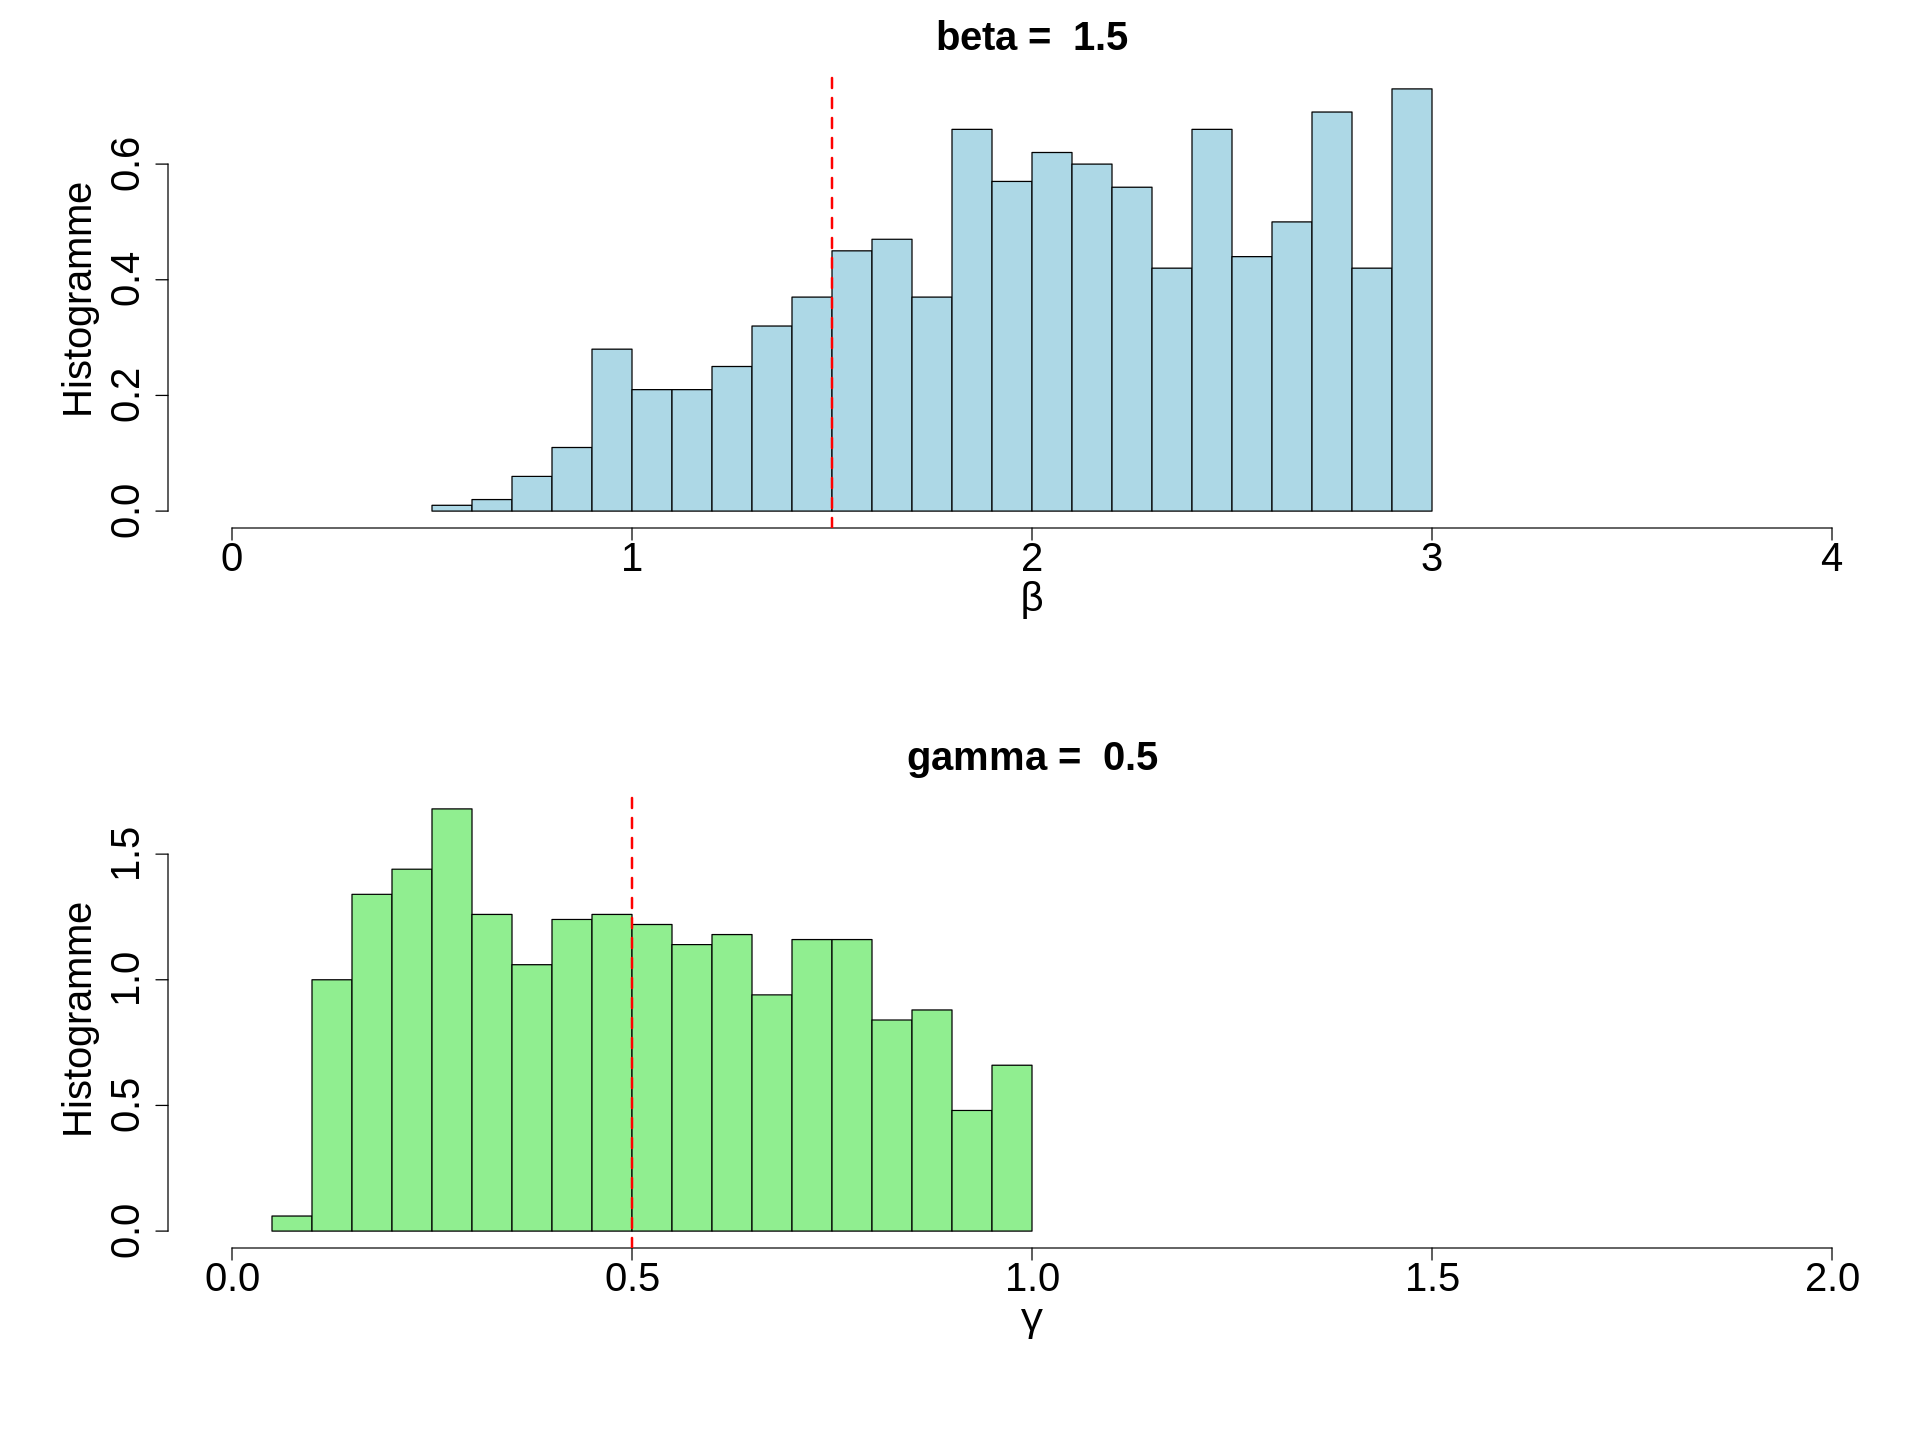

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# Type 3
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

# 4 colonnes (S0, beta, gamma, R0)
par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes



  # Résultats du type 3
  res <- all_res_N1000[[2]]



  # =================================================
  # HISTOGRAMME BETA
  # =================================================

  hist(
    res$beta_star,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("beta = ", 1.5),
    xlab = expression(beta),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 4)
  )

  abline(
    v = 1.5,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME GAMMA
  # =================================================

  hist(
    res$gamma_star,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "gamma = ", 0.5 ),
    xlab = expression(gamma),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 2)
  )

  abline(
    v = 0.5,
    col = "red",
    lwd = 2,
    lty = 2
  )